In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [2]:
digits = load_digits()
X, y = digits.data, digits.target
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1797, 64)
y shape: (1797,)


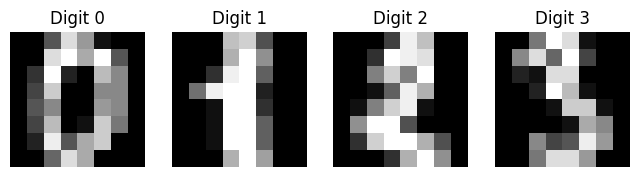

In [3]:
# Show first 4 digits only
plt.figure(figsize=(8, 2))
for i in range(4):
    plt.subplot(1, 4, i+1)  # 1 row, 4 columns, position i+1
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Digit {digits.target[i]}")
    plt.axis('off')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1347, 64)
Test shape: (450, 64)


In [5]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [6]:
y_pred = clf.predict(X_test)
print("First 5 predictions:", y_pred[:5])

First 5 predictions: [6 9 3 8 2]


In [7]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print(f"Percentage correct: {accuracy*100:.1f}%")

Accuracy: 0.858
Percentage correct: 85.8%


In [8]:
# Check first 5: did we guess right?
print("True labels:", y_test[:5])
print("Our guesses:", y_pred[:5])
print("Correct?", y_test[:5] == y_pred[:5])

True labels: [6 9 3 7 2]
Our guesses: [6 9 3 8 2]
Correct? [ True  True  True False  True]


In [9]:
total_correct = sum(y_test[:5] == y_pred[:5])
print(f"First 5: {total_correct} out of 5 correct")

First 5: 4 out of 5 correct


In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.84      0.86      0.85        37
           2       0.89      0.84      0.86        38
           3       0.79      0.83      0.81        46
           4       0.91      0.89      0.90        55
           5       0.89      0.81      0.85        59
           6       0.93      0.96      0.95        45
           7       0.88      0.88      0.88        41
           8       0.69      0.71      0.70        38
           9       0.81      0.88      0.84        48

    accuracy                           0.86       450
   macro avg       0.86      0.86      0.86       450
weighted avg       0.86      0.86      0.86       450



In [11]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[39  0  0  0  3  1  0  0  0  0]
 [ 0 32  1  1  0  0  0  0  3  0]
 [ 0  1 32  3  0  1  0  0  1  0]
 [ 0  0  0 38  0  1  0  1  3  3]
 [ 0  1  0  0 49  1  2  2  0  0]
 [ 0  1  1  1  1 48  1  1  1  4]
 [ 2  0  0  0  0  0 43  0  0  0]
 [ 0  0  0  0  0  2  0 36  2  1]
 [ 1  3  2  2  1  0  0  0 27  2]
 [ 0  0  0  3  0  0  0  1  2 42]]


In [12]:
wrong = y_test != y_pred
print("Total wrong:", sum(wrong))

Total wrong: 64


In [13]:
wrong = y_test != y_pred
print(wrong[:10])
print(sum(wrong))

[False False False  True False False False  True False False]
64


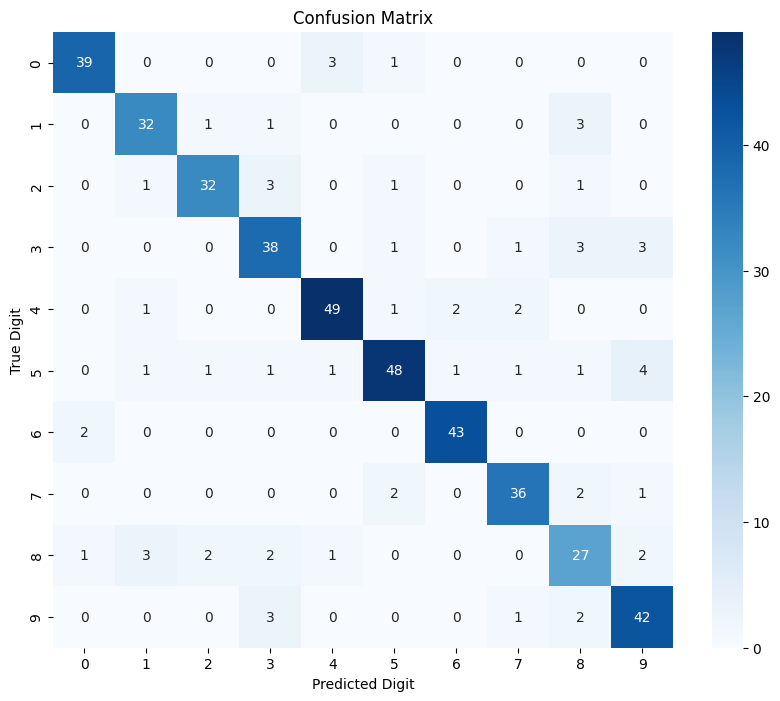

In [14]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Digit')
plt.xlabel('Predicted Digit')
plt.show()

In [15]:
clf2 = DecisionTreeClassifier(max_depth=5, random_state=42)
clf2.fit(X_train, y_train)
print("Shallow tree trained")

Shallow tree trained


In [16]:
y_pred2 = clf2.predict(X_test)
accuracy2 = accuracy_score(y_test, y_pred2)
print(f"Original tree:  {accuracy:.3f}")
print(f"Shallow tree:    {accuracy2:.3f}")

Original tree:  0.858
Shallow tree:    0.669


In [17]:
clf3 = DecisionTreeClassifier(max_depth=10, random_state=42)
clf3.fit(X_train, y_train)
y_pred3 = clf3.predict(X_test)
accuracy3 = accuracy_score(y_test, y_pred3)
print(f"Original:  {accuracy:.3f}")
print(f"Depth 5:   {accuracy2:.3f}")
print(f"Depth 10:  {accuracy3:.3f}")

Original:  0.858
Depth 5:   0.669
Depth 10:  0.867


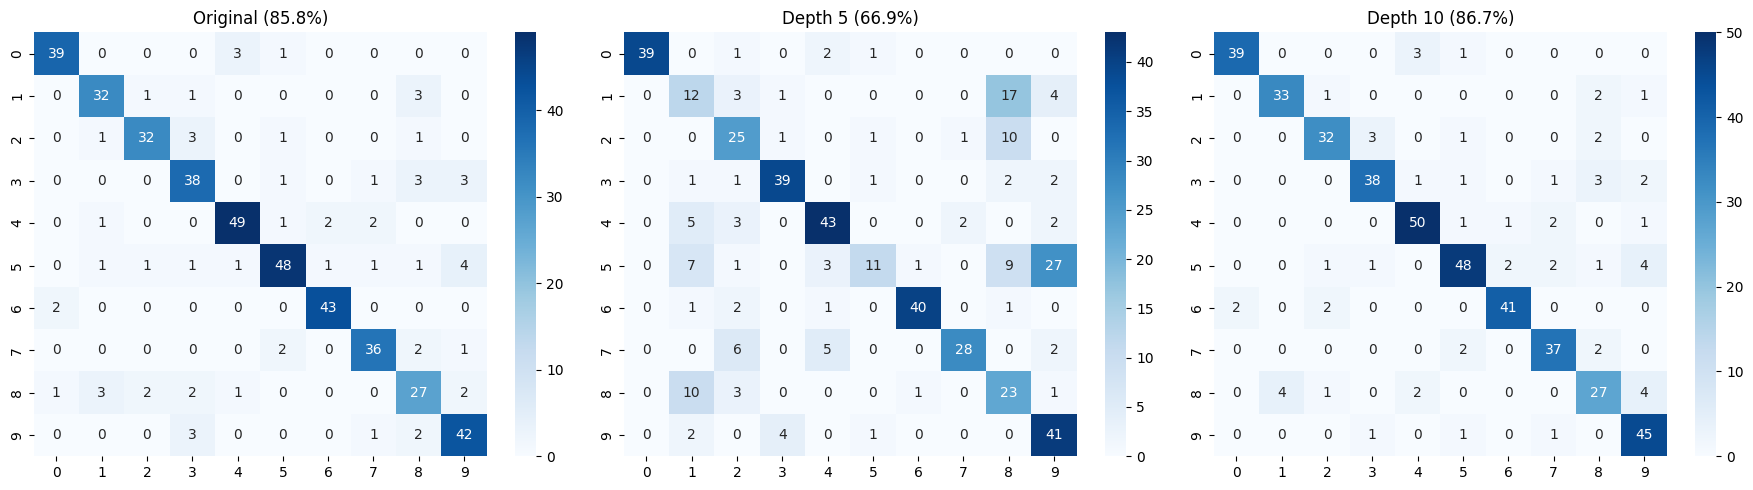

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original tree
cm1 = confusion_matrix(y_test, y_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Original (85.8%)')

# Depth 5 (bad)
cm2 = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Depth 5 (66.9%)')

# Depth 10 (best!)
cm3 = confusion_matrix(y_test, y_pred3)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Depth 10 (86.7%)')

plt.tight_layout()
plt.show()

In [19]:
from sklearn.linear_model import LogisticRegression
log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [20]:
y_pred_log = log_clf.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Best tree:     {accuracy3:.3f}")
print(f"Logistic Reg:  {accuracy_log:.3f}")

Best tree:     0.867
Logistic Reg:  0.973


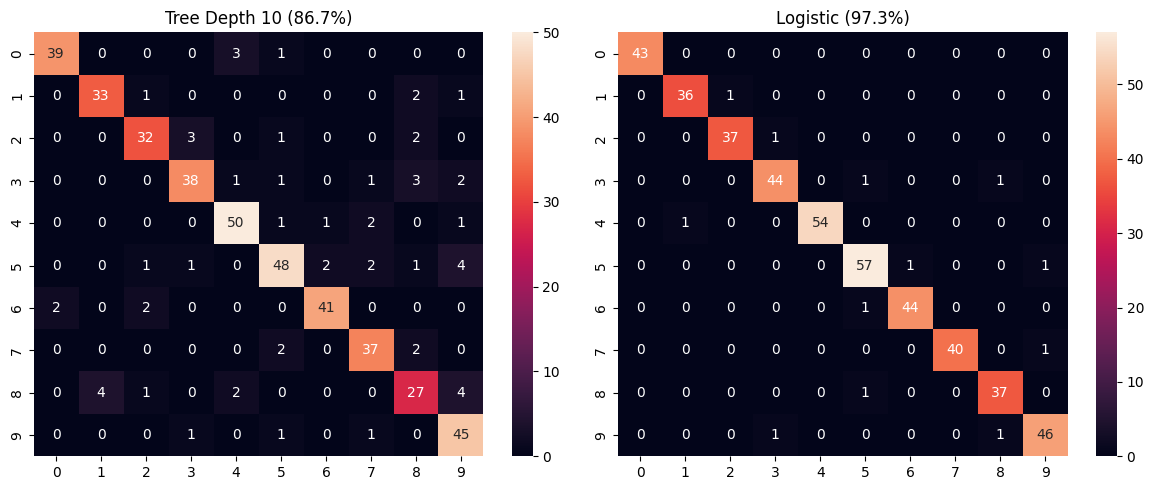

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Tree (depth 10) vs Logistic
cm_tree = confusion_matrix(y_test, y_pred3)
cm_log = confusion_matrix(y_test, y_pred_log)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_tree, annot=True, fmt='d', ax=ax1)
ax1.set_title('Tree Depth 10 (86.7%)')
sns.heatmap(cm_log, annot=True, fmt='d', ax=ax2)
ax2.set_title('Logistic (97.3%)')
plt.tight_layout()
plt.show()

In this notebook, I built a simple machine learning project using the handwritten digits dataset from scikit-learn. The goal was to classify digits from 0 to 9 based on their pixel values.

I first trained a decision tree model to see how well a rule-based approach could separate the digits. Then I trained a logistic regression model, which uses all pixel values together to make a prediction.

After comparing the results, logistic regression performed much better than the decision tree. The decision tree reached an accuracy of 0.867, while logistic regression reached an accuracy of 0.973.

This shows that for this dataset, logistic regression was the stronger model because it produced fewer mistakes and a cleaner confusion matrix.